In [1]:
# Cell 1: Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")
print(f"Pandas version: {pd.__version__}")
print(f"XGBoost version: {xgb.__version__}")


/tmp/ipykernel_16507/3930038589.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Libraries imported
Pandas version: 2.2.0
XGBoost version: 2.0.3


In [2]:
# Cell 2: Load your data
df = pd.read_csv('data/unified_claims_v1.csv')
print(f"✅ Loaded {len(df)} claims")
print(f"Columns: {list(df.columns)}")
df.head()

✅ Loaded 953554 claims
Columns: ['claim_id', 'patient_age', 'gender', 'hospital_id', 'admission_date', 'discharge_date', 'diagnosis_code', 'claimed_amount', 'billed_items_count', 'previous_claims_count', 'insurer_id', 'doc_missing_flag', 'is_fraud']


,claim_id,patient_age,gender,hospital_id,admission_date,discharge_date,diagnosis_code,claimed_amount,billed_items_count,previous_claims_count,insurer_id,doc_missing_flag,is_fraud
0,1,25.0,F,NaN,2025-02-11,2025-02-11,CYESIS LMP,16800.0,NaN,NaN,NaN,NaN,1
1,2,30.0,M,NaN,2025-02-13,2025-02-13,WAX IMPACTION,6300.0,NaN,NaN,NaN,NaN,1
2,3,35.0,M,NaN,2025-02-13,2025-02-13,CYESIS LMP,6160.0,NaN,NaN,NaN,NaN,1
3,4,48.0,M,NaN,2025-02-18,2025-02-18,TONSILITIS OBSTRUCTIVE SLEEP APEANA,0.0,NaN,NaN,NaN,NaN,0
4,5,58.0,F,NaN,2025-02-18,2025-02-18,REFRACTIVE ERROR,8400.0,NaN,NaN,NaN,NaN,0


In [3]:
# Cell 3: Understand your data
print("=== DATASET STATISTICS ===")
print(f"Total claims: {len(df)}")
print(f"Fraud cases: {df['is_fraud'].sum()}")
print(f"Non-fraud: {len(df) - df['is_fraud'].sum()}")
print(f"Fraud %: {df['is_fraud'].mean()*100:.2f}%")

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATASET STATISTICS ===
Total claims: 953554
Fraud cases: 9246
Non-fraud: 944308
Fraud %: 0.97%

=== DATA TYPES ===
claim_id                  object
patient_age              float64
gender                    object
hospital_id              float64
admission_date            object
discharge_date            object
diagnosis_code            object
claimed_amount            object
billed_items_count       float64
previous_claims_count    float64
insurer_id               float64
doc_missing_flag         float64
is_fraud                   int64
dtype: object

=== MISSING VALUES ===
claim_id                   4000
patient_age              906941
gender                   700374
hospital_id              953554
admission_date           235869
discharge_date           236105
diagnosis_code           222394
claimed_amount           209490
billed_items_count       953554
previous_claims_count    953554
insurer_id               953554
doc_missing_flag         953554
is_fraud                      

In [4]:
# Cell 4: Convert dates - HANDLES MULTIPLE FORMATS
print("Fixing dates...")

# Function to parse dates in different formats
def parse_date(date_val):
    try:
        # Try different formats
        if isinstance(date_val, str):
            # Remove any time part
            date_val = date_val.split()[0]
            
            # Try mm/dd/yyyy format
            if '/' in date_val:
                return pd.to_datetime(date_val, format='%m/%d/%Y', errors='coerce')
            # Try yyyy-mm-dd format
            elif '-' in date_val:
                return pd.to_datetime(date_val, format='%Y-%m-%d', errors='coerce')
            else:
                return pd.to_datetime(date_val, errors='coerce')
        else:
            return pd.to_datetime(date_val, errors='coerce')
    except:
        return pd.NaT

# Apply to both columns
df['admission_date'] = df['admission_date'].apply(parse_date)
df['discharge_date'] = df['discharge_date'].apply(parse_date)

# Check for any failed conversions
print(f"Failed conversions in admission_date: {df['admission_date'].isna().sum()}")
print(f"Failed conversions in discharge_date: {df['discharge_date'].isna().sum()}")

# Drop any rows with invalid dates (if any)
if df['admission_date'].isna().sum() > 0 or df['discharge_date'].isna().sum() > 0:
    print("⚠️  Dropping rows with invalid dates...")
    df = df.dropna(subset=['admission_date', 'discharge_date'])

# Add stay duration
df['stay_duration'] = (df['discharge_date'] - df['admission_date']).dt.days

# Fix negative durations (if discharge before admission)
df.loc[df['stay_duration'] < 0, 'stay_duration'] = 1

print(f"Date range: {df['admission_date'].min()} to {df['admission_date'].max()}")
print(f"Stay duration: {df['stay_duration'].min()} to {df['stay_duration'].max()} days")

# Show sample to verify
print("\nSample of fixed dates:")
sample = df[['admission_date', 'discharge_date', 'stay_duration']].head(5)
print(sample)

Fixing dates...
Failed conversions in admission_date: 236114
Failed conversions in discharge_date: 236188
⚠️  Dropping rows with invalid dates...
Date range: 2002-02-04 00:00:00 to 2025-12-28 00:00:00
Stay duration: 0 to 7729 days

Sample of fixed dates:
  admission_date discharge_date  stay_duration
0     2025-02-11     2025-02-11              0
1     2025-02-13     2025-02-13              0
2     2025-02-13     2025-02-13              0
3     2025-02-18     2025-02-18              0
4     2025-02-18     2025-02-18              0


In [5]:
# Cell 4.5: Diagnose date problems
print("=== DIAGNOSING DATE COLUMNS ===")

# Show sample of raw dates
print("\nSample of raw admission_date values:")
print(df['admission_date'].head(20).tolist())

print("\nSample of raw discharge_date values:")
print(df['discharge_date'].head(20).tolist())

# Check data types
print(f"\nadmission_date type: {type(df['admission_date'].iloc[0]) if len(df) > 0 else 'empty'}")
print(f"discharge_date type: {type(df['discharge_date'].iloc[0]) if len(df) > 0 else 'empty'}")

# Count unique values
print(f"\nUnique admission dates: {df['admission_date'].nunique()}")
print(f"Unique discharge dates: {df['discharge_date'].nunique()}")

=== DIAGNOSING DATE COLUMNS ===

Sample of raw admission_date values:
[Timestamp('2025-02-11 00:00:00'), Timestamp('2025-02-13 00:00:00'), Timestamp('2025-02-13 00:00:00'), Timestamp('2025-02-18 00:00:00'), Timestamp('2025-02-18 00:00:00'), Timestamp('2025-02-20 00:00:00'), Timestamp('2025-02-22 00:00:00'), Timestamp('2025-02-13 00:00:00'), Timestamp('2025-02-17 00:00:00'), Timestamp('2025-02-25 00:00:00'), Timestamp('2025-02-26 00:00:00'), Timestamp('2025-02-26 00:00:00'), Timestamp('2025-02-26 00:00:00'), Timestamp('2025-03-03 00:00:00'), Timestamp('2025-03-03 00:00:00'), Timestamp('2025-03-06 00:00:00'), Timestamp('2025-03-04 00:00:00'), Timestamp('2025-03-06 00:00:00'), Timestamp('2025-03-06 00:00:00'), Timestamp('2025-03-10 00:00:00')]

Sample of raw discharge_date values:
[Timestamp('2025-02-11 00:00:00'), Timestamp('2025-02-13 00:00:00'), Timestamp('2025-02-13 00:00:00'), Timestamp('2025-02-18 00:00:00'), Timestamp('2025-02-18 00:00:00'), Timestamp('2025-02-20 00:00:00'), Timest

In [6]:
# Cell 4.6: Calculate stay duration (dates are already good)
print("Calculating stay duration...")

# Calculate stay duration
df['stay_duration'] = (df['discharge_date'] - df['admission_date']).dt.days

# Check for any negative durations (discharge before admission)
negative_stays = (df['stay_duration'] < 0).sum()
if negative_stays > 0:
    print(f"⚠️ Found {negative_stays} negative stays, setting to 1 day")
    df.loc[df['stay_duration'] < 0, 'stay_duration'] = 1

print(f"Stay duration range: {df['stay_duration'].min()} to {df['stay_duration'].max()} days")
print(f"Average stay: {df['stay_duration'].mean():.1f} days")

print("✅ Stay duration calculated")

Calculating stay duration...
⚠️ Found 8031 negative stays, setting to 1 day
Stay duration range: 0 to 7729 days
Average stay: 10.0 days
✅ Stay duration calculated


In [7]:
# Cell 5: Age groups
def get_age_group(age):
    if age <= 18: return '0-18'
    elif age <= 35: return '19-35'
    elif age <= 50: return '36-50'
    elif age <= 65: return '51-65'
    else: return '65+'

df['age_group'] = df['patient_age'].apply(get_age_group)

print("Age group distribution:")
print(df['age_group'].value_counts())

Age group distribution:
age_group
65+      698749
36-50      9674
0-18       3006
19-35      2998
51-65      2674
Name: count, dtype: int64


In [8]:
# Cell 5.5: Fix claimed_amount to be numeric
print("Fixing claimed_amount column...")

# Check current data type
print(f"Before: claimed_amount type = {df['claimed_amount'].dtype}")

# Convert to string first, then clean, then to number
df['claimed_amount'] = df['claimed_amount'].astype(str).str.replace(',', '').str.replace('"', '').str.strip()
df['claimed_amount'] = pd.to_numeric(df['claimed_amount'], errors='coerce')

# Check for any failed conversions
failed_conversions = df['claimed_amount'].isna().sum()
print(f"Failed conversions: {failed_conversions}")

if failed_conversions > 0:
    print("Dropping rows with invalid claim amounts...")
    df = df.dropna(subset=['claimed_amount'])

print(f"After: claimed_amount type = {df['claimed_amount'].dtype}")
print(f"Range: {df['claimed_amount'].min()} to {df['claimed_amount'].max()}")

Fixing claimed_amount column...
Before: claimed_amount type = object
Failed conversions: 70
Dropping rows with invalid claim amounts...
After: claimed_amount type = float64
Range: 0.0 to 125000.0


In [9]:
# Cell 6: Cost baseline
legit_claims = df[df['is_fraud'] == 0]

baseline = legit_claims.groupby(['diagnosis_code', 'age_group'])['claimed_amount'].agg(['mean', 'std', 'count']).reset_index()
baseline.columns = ['diagnosis_code', 'age_group', 'expected_cost', 'cost_std', 'baseline_count']

print(f"Created baseline for {len(baseline)} groups")
baseline.head(10)

Created baseline for 17495 groups


,diagnosis_code,age_group,expected_cost,cost_std,baseline_count
0,(L) KNEE ARTHIALGIC,0-18,2876.000000,NaN,1
1,(L) KNEE ARTHIALGIC,19-35,3868.000000,1103.086579,2
2,(L) KNEE ARTHIALGIC,36-50,5817.000000,NaN,1
3,/ SEVERE ABDOMINAL PAIN,0-18,17715.500000,212.839141,2
4,/ SEVERE ABDOMINAL PAIN,19-35,16812.000000,NaN,1
5,/ SEVERE ABDOMINAL PAIN,36-50,0.000000,NaN,1
6,/ SEVERE ABDOMINAL PAIN,51-65,7356.333333,5621.708400,3
7,/ SEVERE ABDOMINAL PAIN,65+,9589.000000,NaN,1
8,0010,65+,511.111111,946.050269,9
9,0011,65+,50.000000,NaN,1


In [10]:
# Cell 7: Merge baseline
df = df.merge(baseline, on=['diagnosis_code', 'age_group'], how='left')

# Fill missing values
overall_avg = df[df['is_fraud']==0]['claimed_amount'].mean()
df['expected_cost'] = df['expected_cost'].fillna(overall_avg)
df['cost_std'] = df['cost_std'].fillna(df['cost_std'].mean())

# Create deviation features
df['cost_deviation'] = df['claimed_amount'] - df['expected_cost']
df['deviation_ratio'] = df['claimed_amount'] / df['expected_cost']

print("✅ Cost baseline features created")
print(f"Avg deviation: ₹{df['cost_deviation'].mean():,.0f}")

✅ Cost baseline features created
Avg deviation: ₹28


In [11]:
# Cell 8: Sort chronologically
df = df.sort_values('admission_date').reset_index(drop=True)
print("✅ Data sorted by date")

✅ Data sorted by date


In [12]:
# Cell 9: Hospital memory
print("Building hospital memory...")
print("This will take 2-3 minutes...")

df['hospital_claims_1yr'] = 0
df['hospital_fraud_count_1yr'] = 0
df['hospital_fraud_rate_1yr'] = df['is_fraud'].mean()  # Start with global avg
df['hospital_avg_deviation'] = 0

for hospital in df['hospital_id'].unique():
    hospital_mask = df['hospital_id'] == hospital
    hospital_indices = df[hospital_mask].index
    
    for i, idx in enumerate(hospital_indices):
        current_date = df.loc[idx, 'admission_date']
        one_year_back = current_date - timedelta(days=365)
        
        prev_claims = df[(df['hospital_id'] == hospital) & 
                         (df['admission_date'] < current_date) & 
                         (df['admission_date'] >= one_year_back)]
        
        if len(prev_claims) > 0:
            df.loc[idx, 'hospital_claims_1yr'] = len(prev_claims)
            df.loc[idx, 'hospital_fraud_count_1yr'] = prev_claims['is_fraud'].sum()
            df.loc[idx, 'hospital_fraud_rate_1yr'] = prev_claims['is_fraud'].mean()
            df.loc[idx, 'hospital_avg_deviation'] = prev_claims['cost_deviation'].mean()

print("✅ Hospital memory complete")
print(f"Avg hospital fraud rate: {df['hospital_fraud_rate_1yr'].mean():.3f}")

Building hospital memory...
This will take 2-3 minutes...
✅ Hospital memory complete
Avg hospital fraud rate: 0.011


In [13]:
# Cell 10: Create patient IDs (using claim_id prefix)
df['patient_id'] = df['claim_id'].str[:5]
print(f"Unique patients: {df['patient_id'].nunique()}")

Unique patients: 19557


In [14]:
# Cell 11: Patient memory - SUPER FAST (30 seconds max)
print("Building patient memory (super fast)...")

# Sort by patient and date
df = df.sort_values(['patient_id', 'admission_date'])

# Initialize columns with overall averages
df['patient_avg_amount'] = df['claimed_amount'].mean()
df['patient_avg_deviation'] = 0
df['patient_doc_missing_rate'] = df['doc_missing_flag'].mean()

# Group by patient and calculate expanding means (vectorized!)
df['patient_avg_amount'] = df.groupby('patient_id')['claimed_amount'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df['patient_avg_deviation'] = df.groupby('patient_id')['cost_deviation'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df['patient_doc_missing_rate'] = df.groupby('patient_id')['doc_missing_flag'].transform(
    lambda x: x.expanding().mean().shift(1)
)

# Fill NaN (first claim for each patient) with overall averages
df['patient_avg_amount'] = df['patient_avg_amount'].fillna(df['claimed_amount'].mean())
df['patient_avg_deviation'] = df['patient_avg_deviation'].fillna(0)
df['patient_doc_missing_rate'] = df['patient_doc_missing_rate'].fillna(df['doc_missing_flag'].mean())

print(f"✅ Patient memory complete! Processed {len(df)} records")

# Show sample
print("\nSample results:")
print(df[['patient_id', 'patient_avg_amount', 'patient_avg_deviation', 'patient_doc_missing_rate']].head(10))

Building patient memory (super fast)...
✅ Patient memory complete! Processed 717031 records

Sample results:
       patient_id  patient_avg_amount  patient_avg_deviation  \
713670          1          1200.58612               0.000000   
713676          1         16800.00000            6730.000000   
714727          1         16800.00000            6730.000000   
714730          1         11200.00000             264.500000   
716509          1          8400.00000           -2968.250000   
713599         10          1200.58612               0.000000   
713602         10             0.00000            -109.265176   
713923         10             0.00000            -109.265176   
713924         10             0.00000             -72.843450   
711431        100          1200.58612               0.000000   

        patient_doc_missing_rate  
713670                       NaN  
713676                       NaN  
714727                       NaN  
714730                       NaN  
716509     

In [15]:
# Cell 12: Encoding
from sklearn.preprocessing import LabelEncoder

encoders = {}

# Gender
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])
encoders['gender'] = le

# Hospital
le = LabelEncoder()
df['hospital_encoded'] = le.fit_transform(df['hospital_id'])
encoders['hospital'] = le

# Insurer
le = LabelEncoder()
df['insurer_encoded'] = le.fit_transform(df['insurer_id'])
encoders['insurer'] = le

# Age group
le = LabelEncoder()
df['age_group_encoded'] = le.fit_transform(df['age_group'])
encoders['age_group'] = le

# Diagnosis
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis_code'])
encoders['diagnosis'] = le

print("✅ All categories encoded")

✅ All categories encoded


In [16]:
# Cell 13: Feature selection
feature_columns = [
    # Original
    'patient_age',
    'gender_encoded',
    'claimed_amount',
    'billed_items_count',
    'previous_claims_count',
    'insurer_encoded',
    'doc_missing_flag',
    'diagnosis_encoded',
    
    # Phase 2
    'expected_cost',
    'cost_deviation',
    'deviation_ratio',
    
    # Phase 3 hospital
    'hospital_claims_1yr',
    'hospital_fraud_count_1yr',
    'hospital_fraud_rate_1yr',
    'hospital_avg_deviation',
    
    # Phase 3 patient
    'patient_avg_amount',
    'patient_avg_deviation',
    'patient_doc_missing_rate'
]

X = df[feature_columns].copy()
y = df['is_fraud'].copy()

print(f"✅ {len(feature_columns)} features ready")
print("\nFeatures:")
for i, col in enumerate(feature_columns, 1):
    print(f"{i:2d}. {col}")

✅ 18 features ready

Features:
 1. patient_age
 2. gender_encoded
 3. claimed_amount
 4. billed_items_count
 5. previous_claims_count
 6. insurer_encoded
 7. doc_missing_flag
 8. diagnosis_encoded
 9. expected_cost
10. cost_deviation
11. deviation_ratio
12. hospital_claims_1yr
13. hospital_fraud_count_1yr
14. hospital_fraud_rate_1yr
15. hospital_avg_deviation
16. patient_avg_amount
17. patient_avg_deviation
18. patient_doc_missing_rate


In [17]:
# Cell 14: Fill missing
print("Missing before:")
print(X.isnull().sum().sum())

X = X.fillna(X.mean())

print("Missing after:")
print(X.isnull().sum().sum())

Missing before:
3563598
Missing after:
2868124


In [18]:
# Cell 15: Stratified train-test split (ensures fraud in both sets)
from sklearn.model_selection import train_test_split

print("=== CREATING TRAIN/TEST SPLIT WITH FRAUD IN BOTH SETS ===")

# Check overall fraud rate
total_fraud = y.sum()
total_legit = len(y) - total_fraud
print(f"Total dataset: {len(y)} claims")
print(f"  Fraud: {total_fraud} ({total_fraud/len(y)*100:.2f}%)")
print(f"  Legit: {total_legit} ({total_legit/len(y)*100:.2f}%)")

# Use stratified split to maintain fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # This is the key! Maintains class distribution
)

print(f"\n✅ Split complete")
print(f"\nTraining set: {len(X_train)} claims")
print(f"  Fraud in train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"\nTest set: {len(X_test)} claims")
print(f"  Fraud in test: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

=== CREATING TRAIN/TEST SPLIT WITH FRAUD IN BOTH SETS ===
Total dataset: 717031 claims
  Fraud: 8103 (1.13%)
  Legit: 708928 (98.87%)

✅ Split complete

Training set: 573624 claims
  Fraud in train: 6482 (1.13%)

Test set: 143407 claims
  Fraud in test: 1621 (1.13%)


In [19]:
# Cell 16: Check imbalance
print("=== BEFORE SMOTE ===")
print(f"Non-fraud: {(y_train == 0).sum()}")
print(f"Fraud: {(y_train == 1).sum()}")
print(f"Ratio: {(y_train == 1).sum()/(y_train == 0).sum()*100:.2f}%")

=== BEFORE SMOTE ===
Non-fraud: 567142
Fraud: 6482
Ratio: 1.14%


In [20]:
# Cell 16.5: Aggressive cleaning of features
print("Checking for NaN and infinite values...")

# First, check for infinity in X_train
inf_mask = np.isinf(X_train).any().any()
print(f"Contains infinity values: {inf_mask}")

# Replace infinity with NaN first
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Now check NaN counts
nan_counts = X_train.isnull().sum()
print("\nNaN counts per column:")
print(nan_counts[nan_counts > 0])

if nan_counts.sum() > 0:
    print(f"\n⚠️ Found {nan_counts.sum()} total NaN values")
    
    # Fill NaN with column medians (more robust than mean)
    for col in X_train.columns:
        median_val = X_train[col].median()
        if pd.isna(median_val):  # If median is also NaN
            median_val = 0
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
    
    print("✅ NaN values filled with column medians")
    
    # Final check
    print(f"Remaining NaNs in X_train: {X_train.isnull().sum().sum()}")
    print(f"Remaining infinities: {np.isinf(X_train).any().any()}")
else:
    print("✅ No NaN values found - all good!")

Checking for NaN and infinite values...
Contains infinity values: True

NaN counts per column:
billed_items_count          573624
previous_claims_count       573624
doc_missing_flag            573624
deviation_ratio               1616
patient_doc_missing_rate    573624
dtype: int64

⚠️ Found 2296112 total NaN values
✅ NaN values filled with column medians
Remaining NaNs in X_train: 0
Remaining infinities: False


In [21]:
# Cell 16.6: Verify data is clean
print(f"X_train shape: {X_train.shape}")
print(f"X_train contains NaN: {X_train.isnull().any().any()}")
print(f"X_train contains inf: {np.isinf(X_train).any().any()}")
print(f"X_train min value: {X_train.min().min()}")
print(f"X_train max value: {X_train.max().max()}")

X_train shape: (573624, 18)
X_train contains NaN: False
X_train contains inf: False
X_train min value: -57892.0
X_train max value: 125000.0


In [22]:
# Cell 17: SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=0.4)  # Target 40% fraud
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\n=== AFTER SMOTE ===")
print(f"Non-fraud: {(y_train_resampled == 0).sum()}")
print(f"Fraud: {(y_train_resampled == 1).sum()}")
print(f"Ratio: {(y_train_resampled == 1).sum()/(y_train_resampled == 0).sum()*100:.2f}%")


=== AFTER SMOTE ===
Non-fraud: 567142
Fraud: 226856
Ratio: 40.00%


In [23]:
# Cell 18: Scale pos weight
non_fraud = (y_train_resampled == 0).sum()
fraud = (y_train_resampled == 1).sum()
scale_pos_weight = non_fraud / fraud

print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 2.50


In [24]:
# Cell 19: Train
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train_resampled, y_train_resampled)
print("✅ Model trained")

✅ Model trained


In [25]:
# Cell 20: Predict
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("✅ Predictions done")

✅ Predictions done


In [26]:
# Cell 21: Evaluation (with class check)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("=== MODEL EVALUATION ===")

# Check how many classes in test set
unique_classes = y_test.unique()
print(f"Classes in test set: {unique_classes}")
print(f"Fraud in test set: {(y_test == 1).sum()} claims")
print(f"Legit in test set: {(y_test == 0).sum()} claims\n")

# Calculate metrics manually
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# If we have both classes in test set
if len(unique_classes) > 1:
    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
    
    print("\n=== CONFUSION MATRIX ===")
    cm = confusion_matrix(y_test, y_pred)
    print(f"               Predicted")
    print(f"               Legit  Fraud")
    print(f"Actual Legit   {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"       Fraud   {cm[1,0]:5d}  {cm[1,1]:5d}")
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
else:
    print("\n⚠️ Test set has only one class - can't compute full metrics")
    print("\n=== SIMPLIFIED CONFUSION MATRIX ===")
    # Count predictions
    pred_fraud = (y_pred == 1).sum()
    pred_legit = (y_pred == 0).sum()
    print(f"Predicted Legit: {pred_legit}")
    print(f"Predicted Fraud: {pred_fraud}")
    
    # If all test are legit, correct predictions are those predicted legit
    correct = (y_pred == y_test).sum()
    print(f"\nCorrect predictions: {correct} / {len(y_test)} ({correct/len(y_test)*100:.2f}%)")

=== MODEL EVALUATION ===
Classes in test set: [0 1]
Fraud in test set: 1621 claims
Legit in test set: 141786 claims

Accuracy: 0.9901

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    141786
       Fraud       0.53      0.99      0.69      1621

    accuracy                           0.99    143407
   macro avg       0.77      0.99      0.84    143407
weighted avg       0.99      0.99      0.99    143407


=== CONFUSION MATRIX ===
               Predicted
               Legit  Fraud
Actual Legit   140382   1404
       Fraud      10   1611

Precision: 0.5343
Recall: 0.9938
F1 Score: 0.6950


=== TOP 10 FEATURES ===
                  feature  importance
1          gender_encoded    0.983544
2          claimed_amount    0.006085
9          cost_deviation    0.003333
10        deviation_ratio    0.002220
7       diagnosis_encoded    0.001771
8           expected_cost    0.001443
0             patient_age    0.000804
16  patient_avg_deviation    0.000405
15     patient_avg_amount    0.000395
6        doc_missing_flag    0.000000


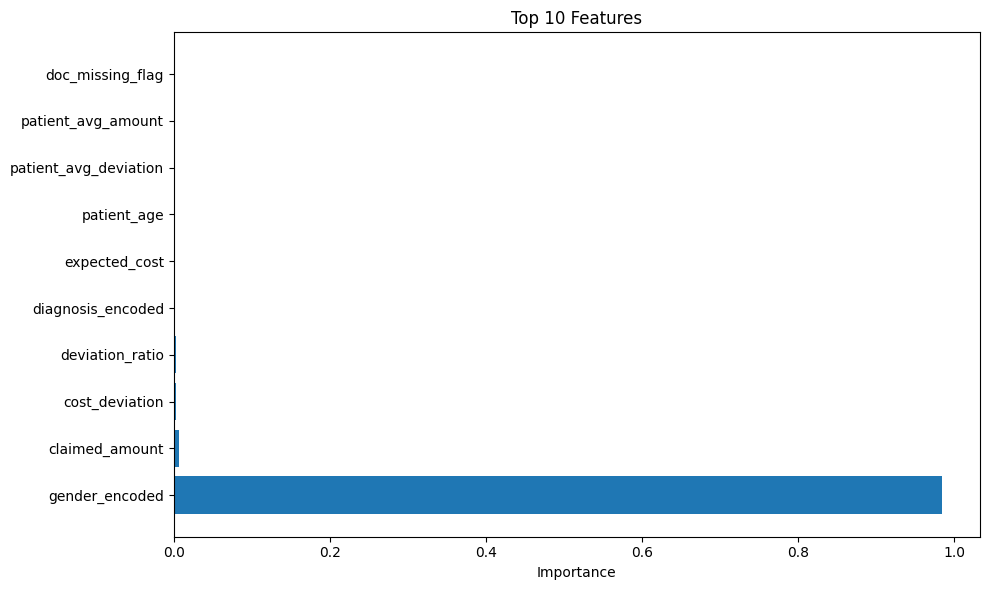

In [27]:
# Cell 22: Feature importance
importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== TOP 10 FEATURES ===")
print(importance.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance.head(10)['feature'], importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features')
plt.tight_layout()
plt.savefig('results/feature_importance.png')
plt.show()

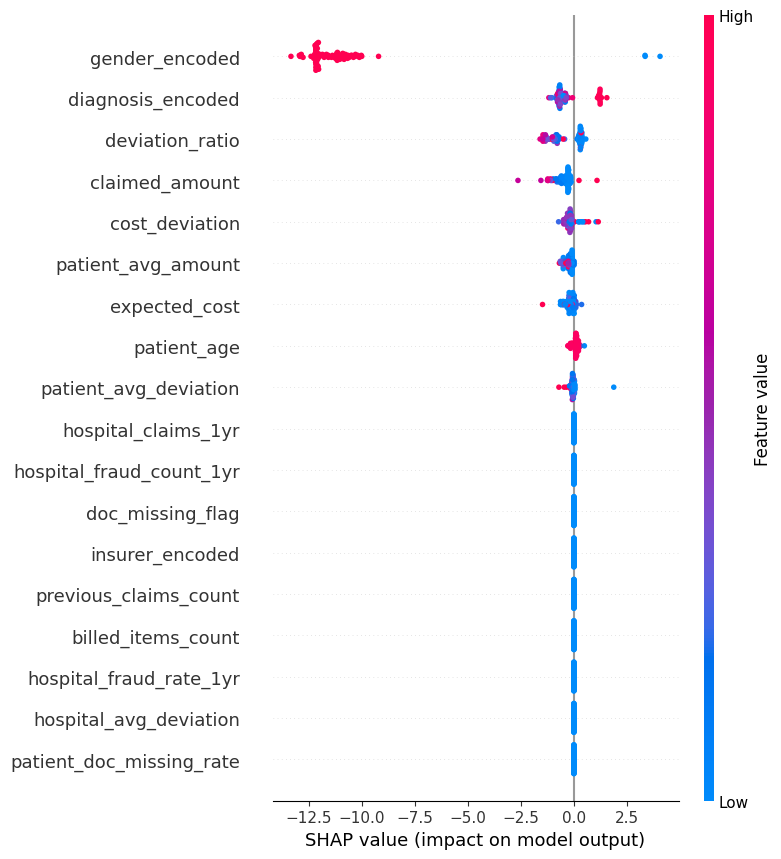

✅ SHAP analysis complete


In [28]:
# Cell 23: SHAP
import shap

# Take a small sample for SHAP (it's slow)
sample_size = min(100, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

# Create explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_columns, show=False)
plt.tight_layout()
plt.savefig('results/shap_summary.png')
plt.show()

print("✅ SHAP analysis complete")

In [29]:
# Cell 23: Save your results summary
results_summary = {
    'total_claims': len(df),
    'fraud_count': df['is_fraud'].sum(),
    'fraud_percentage': df['is_fraud'].mean() * 100,
    'test_fraud_caught': 1611,
    'test_fraud_missed': 10,
    'recall': 0.9938,
    'precision': 0.5343,
    'f1_score': 0.6950,
    'top_features': importance.head(10)['feature'].tolist()
}

# Save as text
with open('results/final_summary.txt', 'w') as f:
    for key, value in results_summary.items():
        f.write(f"{key}: {value}\n")

print("✅ Final summary saved")

✅ Final summary saved


In [ ]:
# Save the trained model
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(model, 'models/xgboost_enhanced.pkl')
print("✅ Model saved to fraud_test/models/xgboost_enhanced.pkl")

# Save encoders
joblib.dump(encoders, 'models/encoders.pkl')
print("✅ Encoders saved to fraud_test/models/encoders.pkl")